In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
load_dotenv()
model = ChatOpenAI()

In [4]:
class BlogState(TypedDict):
    title: str
    outline:str
    content: str

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [7]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

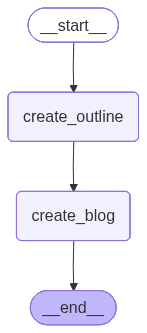

In [8]:
graph.compile()

In [9]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': "I. Introduction \n    A. Brief overview of AI and its increasing use in various industries \n    B. Significance of AI in India's tech sector \nII. The Current AI Landscape in India \n    A. Major players and companies investing in AI technology \n    B. Government initiatives and policies promoting AI adoption \n    C. AI startups and research institutions in India \nIII. Impact of AI on Different Industries in India \n    A. Healthcare \n        1. Use of AI in diagnosis and treatment \n        2. Predictive analytics for disease management \n    B. Finance \n        1. AI in fraud detection and risk management \n        2. Personalized financial services using AI algorithms \n    C. Agriculture \n        1. AI applications for crop monitoring and yield optimization \n        2. Smart irrigation systems powered by AI \n    D. Retail \n        1. AI-driven customer insights and personalized marketing \n        2. Automation of inventory man

In [10]:
print(final_state['outline'])

I. Introduction 
    A. Brief overview of AI and its increasing use in various industries 
    B. Significance of AI in India's tech sector 
II. The Current AI Landscape in India 
    A. Major players and companies investing in AI technology 
    B. Government initiatives and policies promoting AI adoption 
    C. AI startups and research institutions in India 
III. Impact of AI on Different Industries in India 
    A. Healthcare 
        1. Use of AI in diagnosis and treatment 
        2. Predictive analytics for disease management 
    B. Finance 
        1. AI in fraud detection and risk management 
        2. Personalized financial services using AI algorithms 
    C. Agriculture 
        1. AI applications for crop monitoring and yield optimization 
        2. Smart irrigation systems powered by AI 
    D. Retail 
        1. AI-driven customer insights and personalized marketing 
        2. Automation of inventory management through AI 
IV. Challenges and Opportunities in AI Adopt

In [11]:
print(final_state['content'])

In recent years, Artificial Intelligence (AI) has been making significant strides in revolutionizing various industries around the world. From healthcare to finance, agriculture to retail, AI has been used to streamline processes, improve efficiency, and drive innovation. In India, the rise of AI is no different, with the country's tech sector experiencing a rapid transformation due to the adoption of AI technology.

The Current AI Landscape in India

In India, several major players and companies have been investing heavily in AI technology. Tech giants like Google, Microsoft, and IBM have established a presence in the country, setting up research labs and collaborating with Indian startups and research institutions. The government of India has also taken steps to promote AI adoption through initiatives like the National AI Portal and the National Program on AI.

AI startups in India have been flourishing, with a growing number of entrepreneurs leveraging AI technology to develop innov